In [144]:
import pathlib

from lxml import etree
import matplotlib.pyplot as plt
import numpy as np

from sarkit.verification._sicd_consistency import SicdConsistency
from sarkit.verification._sicdcheck import main

DATAPATH = pathlib.Path("/home/vscuser/repos/sarkit-local/data")


In [113]:
def _not_simple(poly_elem):
    old_index = poly_elem[-2].get("index")
    poly_elem[-2].set("index", poly_elem[-1].get("index"))
    poly_elem[-1].set("index", old_index)

In [114]:
def _not_simple1(poly_elem):
    sz = int(poly_elem.get("size"))
    old_index = poly_elem[int(sz/2)].get("index")
    poly_elem[int(sz/2)].set("index", poly_elem[-1].get("index"))
    poly_elem[-1].set("index", old_index)


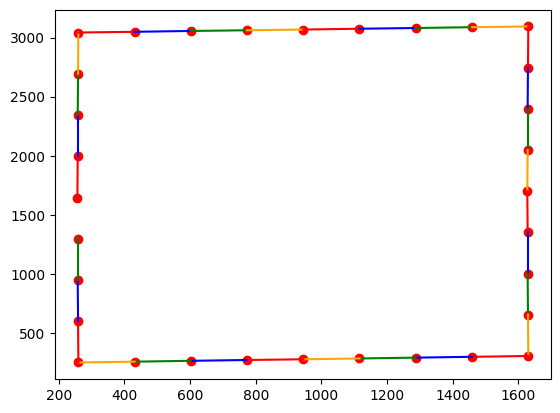

True


In [ ]:
import shapely.geometry as shg
xmltree = etree.parse(DATAPATH / "example-sicd-1.5.xml")
sicd_con = SicdConsistency.from_parts(xmltree)
vert1 = sicd_con.xmlhelp.load("{*}ImageData/{*}ValidData")
x = [v[0] for v in vert1]
y = [v[1] for v in vert1]
plt.scatter(x, y, color='red')

colors = ['red', 'blue', 'green', 'orange']
for i in range(len(x) - 1):
    plt.plot(x[i:i+2], y[i:i+2], color=colors[i % len(colors)], zorder=1)
plt.show()

shg_polygon = shg.Polygon(vert1)
print(shg_polygon.is_simple)


In [154]:
vert2 = np.append(vert1, [vert1[1]], axis=0)
print(vert2)
shg_polygon = shg.Polygon(vert2)
print(shg_polygon.is_simple)


[[ 257 1646]
 [ 258 1995]
 [ 258 2345]
 [ 259 2694]
 [ 260 3043]
 [ 431 3049]
 [ 602 3056]
 [ 773 3062]
 [ 945 3068]
 [1116 3075]
 [1287 3081]
 [1459 3088]
 [1630 3094]
 [1629 2745]
 [1628 2397]
 [1628 2048]
 [1627 1700]
 [1628 1351]
 [1628 1002]
 [1629  654]
 [1630  305]
 [1459  298]
 [1287  291]
 [1116  284]
 [ 945  277]
 [ 773  271]
 [ 602  264]
 [ 431  257]
 [ 260  250]
 [ 259  599]
 [ 258 1297]
 [ 258  948]
 [ 258 1995]]
False


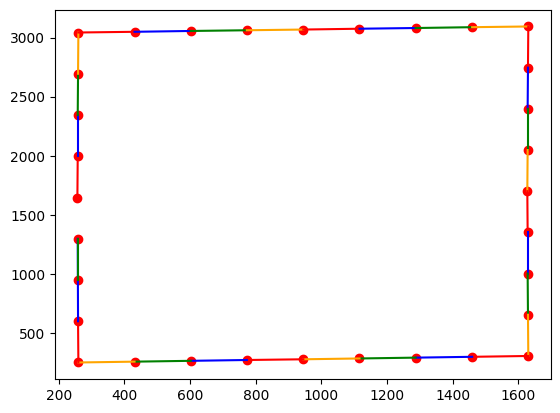

True


In [ ]:
xmltree = etree.parse(DATAPATH / "example-sicd-1.5.xml")
sicd_con = SicdConsistency.from_parts(xmltree)
_not_simple1(sicd_con.sicdroot.find("{*}ImageData/{*}ValidData"))
vert1 = sicd_con.xmlhelp.load("{*}ImageData/{*}ValidData")
#_not_simple1(sicd_con.sicdroot.find("{*}GeoData/{*}ValidData"))
#vert1 = sicd_con.xmlhelp.load("{*}GeoData/{*}ValidData")
x = [v[0] for v in vert1]
y = [v[1] for v in vert1]
plt.scatter(x, y, color='red')



colors = ['red', 'blue', 'green', 'orange']
for i in range(len(x) - 1):
    plt.plot(x[i:i+2], y[i:i+2], color=colors[i % len(colors)], zorder=1)
#plt.plot(x + [x[0]], y + [y[0]], linestyle='-')
plt.show()

shg_polygon = shg.Polygon(vert1)
print(shg_polygon.is_simple)


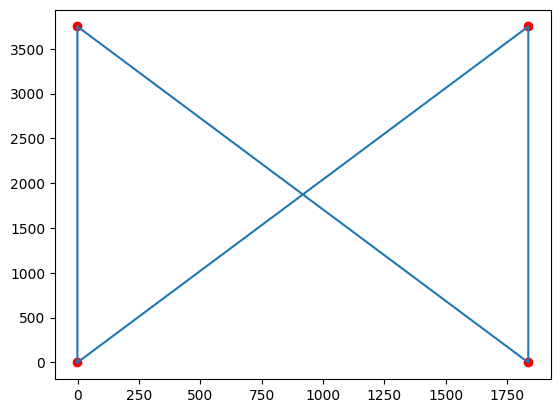

In [116]:
xmltree = etree.parse(DATAPATH / "example-sicd-1.5.xml")
sicd_con = SicdConsistency.from_parts(xmltree)
_not_simple1(sicd_con.sicdroot.find("{*}RadarCollection/{*}Area/{*}Plane/{*}Polygon"))
vert1 = sicd_con.xmlhelp.load("{*}RadarCollection/{*}Area/{*}Plane/{*}Polygon")
x = [v[0] for v in vert1]
y = [v[1] for v in vert1]
plt.scatter(x, y, color='red')
plt.plot(x + [x[0]], y + [y[0]], linestyle='-')
plt.show()

In [ ]:
import copy
import numpy as np

xmltree = etree.parse(DATAPATH / "example-sicd-1.5.xml")
sicd_con = SicdConsistency.from_parts(copy.deepcopy(xmltree))
vertices = sicd_con.xmlhelp.load("./{*}GeoData/{*}ValidData")
shg_polygon = shg.Polygon(vertices)
print(shg_polygon.exterior.is_ccw)
#row = [vertex[0] for vertex in vertices]
#col = [vertex[1] for vertex in vertices if vertex[0] == min(row)]
print(vertices[0:3])
poly_elem = sicd_con.sicdroot.find("./{*}GeoData/{*}ValidData")
for vertex in poly_elem:
    vertex.set("index", str(len(poly_elem) + 1 - int(vertex.get("index"))))
vertices1 = sicd_con.xmlhelp.load("./{*}GeoData/{*}ValidData")
print(vertices1[0:3])


shg_polygon = shg.Polygon(vertices1)
print(shg_polygon.exterior.is_ccw)
shg_polygon = shg.Polygon(vertices1[::-1])
print(shg_polygon.exterior.is_ccw)

#sicd_con.check("check_validdata_first_vertex")
#assert not sicd_con.failures()



True
[[-0.0066583   0.0012848 ]
 [-0.00730503 -0.00202206]
 [-0.00795176 -0.00532892]]
[[-0.00601157  0.00459167]
 [-0.00536484  0.00789853]
 [-0.0047181   0.01120539]]
False
True


In [195]:
import copy
import numpy as np

xmltree = etree.parse(DATAPATH / "example-sicd-1.5.xml")
sicd_con = SicdConsistency.from_parts(copy.deepcopy(xmltree))
vertices = sicd_con.xmlhelp.load("./{*}GeoData/{*}ValidData")
shg_polygon = shg.Polygon(vertices)
print(shg_polygon.exterior.is_ccw)


False
